# Harbour Surveillance — Multi-Sensor Simulation Environment
**Autonomous Marine Robotics — Course Project**
**DTU Department of Electrical and Photonics Engineering — CREA Group**

---

## Overview
This notebook implements the **simulation environment** for the harbour surveillance project.
It generates synthetic sensor data for five mandatory scenarios, ready to be consumed by the EKF tracker.

### Reference frame
All positions are in **NED (North-East-Down)**, 2-D. Origin = mm-wave radar position.
Bearing convention: measured from North, clockwise → `atan2(East, North)`.

### Sensor suite

| Sensor | Platform | Rate | Range | FOV | Output |
|--------|----------|------|-------|-----|--------|
| mm-wave radar | Land (NED origin) | 0.3 Hz | 1 000 m | 360° | (range, bearing) |
| Stereo camera | Land (offset) | 0.5 Hz | 500 m | 180° | (range, bearing) |
| AIS receiver | Vessel (moving) | ~1/3 Hz | 5 000 m | 360° | NED position |
| GNSS receiver | Vessel (moving) | 1 Hz | — | — | NED position |

### Scenarios
| | Description | Sensors | Duration |
|---|---|---|---|
| **A** | Single target — radar only | Radar | 120 s |
| **B** | Single target — radar + camera | Radar + Camera | 120 s |
| **C** | AIS-equipped target + dropout | All | 150 s |
| **D** | 4 targets, crossing trajectories | Radar + Camera | 120 s |
| **E** | 6 targets, mixed AIS/non-AIS | All | 180 s |


## Section 0 — Imports and setup

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc, FancyArrow
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
import json, os, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
np.random.seed(42)

# Output directory
OUT_DIR = Path("harbour_sim_output")
OUT_DIR.mkdir(exist_ok=True)

print("Imports OK.")
print(f"Output directory: {OUT_DIR.resolve()}")


Imports OK.
Output directory: /home/tarcs/Documents/dtu/26_1/AMR/AMR_Group1/harbour_sim_output


## Section 1 — Data structures

Two lightweight dataclasses carry all data through the pipeline:
- `TargetConfig` — initial kinematic state and metadata for one simulated target.
- `Measurement` — a single sensor return at a given time (true detection or false alarm).
- `SimulationOutput` — full result bundle returned by the simulation engine.


In [18]:
@dataclass
class TargetConfig:
    """Initial configuration for one simulated marine target."""
    target_id      : int
    initial_north  : float          # m, NED
    initial_east   : float          # m, NED
    velocity_north : float          # m/s
    velocity_east  : float          # m/s
    has_ais        : bool  = False  # True → target broadcasts AIS
    active_from    : float = 0.0   # s — target enters the scene at this time
    active_until   : Optional[float] = None  # s — None means stays forever


@dataclass
class Measurement:
    """One sensor return (true detection or false alarm)."""
    sensor_id     : str    # 'radar' | 'camera' | 'ais' | 'gnss'
    time          : float  # seconds since simulation start
    is_false_alarm: bool
    target_id     : int    # true target ID; -1 for false alarms / GNSS
    # Range-bearing (radar, camera) — metres / radians
    range_m       : Optional[float] = None
    bearing_rad   : Optional[float] = None
    # NED position (AIS, GNSS) — metres
    north_m       : Optional[float] = None
    east_m        : Optional[float] = None


@dataclass
class SimulationOutput:
    """Complete output of one simulation run."""
    scenario_name     : str
    dt_true           : float                    # GT propagation step [s]
    t_end             : float                    # simulation duration [s]
    ground_truth      : Dict[int, np.ndarray]    # {target_id: (T,4) states}
    ground_truth_times: np.ndarray               # (T,) time axis for GT
    measurements      : List[Measurement]        # sorted by time
    vessel_positions  : np.ndarray               # (T_gnss, 2) NED vessel pos
    vessel_times      : np.ndarray               # (T_gnss,) GNSS times
    sensor_configs    : Dict                     # parameter summary

print("Data structures defined.")


Data structures defined.


## Section 2 — Constant-velocity motion model

State vector: **x = [N, E, vN, vE]** in the NED frame.

Process noise models unmodelled accelerations (sea current, engine variation)
as white-noise accelerations with std `sigma_a` [m/s²].


In [19]:
class CVMotionModel:
    """
    Discrete-time constant-velocity model in 2-D NED.
    State: x = [p_N, p_E, v_N, v_E]  (metres, m/s)

    F  — 4×4 state transition matrix
    Q  — 4×4 process noise covariance (DWNA model)
    """
    def __init__(self, dt: float, sigma_a: float = 0.05):
        self.dt      = dt
        self.sigma_a = sigma_a
        dt2, dt3, dt4 = dt**2, dt**3, dt**4
        self._F = np.array([
            [1, 0, dt,  0],
            [0, 1,  0, dt],
            [0, 0,  1,  0],
            [0, 0,  0,  1],
        ], dtype=float)
        q = sigma_a**2
        self._Q = q * np.array([
            [dt4/4,     0, dt3/2,     0],
            [    0, dt4/4,     0, dt3/2],
            [dt3/2,     0,   dt2,     0],
            [    0, dt3/2,     0,   dt2],
        ])

    @property
    def F(self) -> np.ndarray:
        return self._F.copy()

    @property
    def Q(self) -> np.ndarray:
        return self._Q.copy()

    def propagate(self, state: np.ndarray, add_noise: bool = True) -> np.ndarray:
        """Advance state [N, E, vN, vE] forward by dt."""
        x = self._F @ state
        if add_noise:
            x += np.random.multivariate_normal(np.zeros(4), self._Q)
        return x


# ── Sanity check ──────────────────────────────────────────────────────────────
_m = CVMotionModel(dt=1.0, sigma_a=0.1)
_x = np.array([0., 0., 2., 1.])
_x2 = _m.propagate(_x, add_noise=False)
assert abs(_x2[0] - 2.0) < 1e-9 and abs(_x2[1] - 1.0) < 1e-9, "CV propagation failed"
print(f"CV model OK  |  F[0,2]={_m.F[0,2]}, F[1,3]={_m.F[1,3]}  (both should equal dt=1.0)")
print(f"Q diagonal: {np.diag(_m.Q).round(6)}  (should be [0.0025, 0.0025, 0.01, 0.01])")


CV model OK  |  F[0,2]=1.0, F[1,3]=1.0  (both should equal dt=1.0)
Q diagonal: [0.0025 0.0025 0.01   0.01  ]  (should be [0.0025, 0.0025, 0.01, 0.01])


## Section 3 — Sensor models

### Coordinate convention
All sensors produce measurements expressed in the NED frame.
Bearing is measured **from North, clockwise**: `φ = atan2(ΔE, ΔN)`.

### Sensor positions
- **Radar**: NED origin `[0, 0]` — measurement model reduces to the Exercise 1 model exactly.
- **Stereo camera**: known NED offset `s_c = [-80, 120]` m from the radar.
- **AIS**: vessel position `v(t)` from the GNSS fix (time-varying offset).


In [20]:
# ── Shared helpers ─────────────────────────────────────────────────────────────

def wrap_angle(a: float) -> float:
    """Wrap angle to (−π, π]."""
    return (a + np.pi) % (2 * np.pi) - np.pi


def range_bearing(sensor_ned: np.ndarray, target_ned: np.ndarray
                  ) -> Tuple[float, float]:
    """
    (range [m], bearing [rad]) from sensor to target in NED.
    bearing = atan2(ΔEast, ΔNorth)  — from North, clockwise.
    """
    d   = target_ned - sensor_ned
    r   = float(np.linalg.norm(d))
    phi = float(np.arctan2(d[1], d[0]))   # atan2(East, North)
    return r, phi


# ══════════════════════════════════════════════════════════════════════════════
class RadarSensor:
    """
    mm-wave radar — land-based, NED origin [0, 0].

    Rate  : 0.3 Hz  (scan every 1/0.3 ≈ 3.33 s)
    Range : 1 000 m
    FOV   : 360°
    Output: (range [m], bearing [rad])
    Noise : σ_r [m], σ_φ [rad], independent
    """
    SENSOR_ID = "radar"

    def __init__(self,
                 sigma_r    : float = 5.0,
                 sigma_phi  : float = np.deg2rad(0.3),
                 range_max  : float = 1000.0,
                 update_rate: float = 0.3,
                 pd         : float = 0.95,
                 lambda_fa  : float = 3.0):
        self.pos_ned     = np.array([0.0, 0.0])
        self.sigma_r     = sigma_r
        self.sigma_phi   = sigma_phi
        self.range_max   = range_max
        self.update_rate = update_rate
        self.dt_scan     = 1.0 / update_rate
        self.pd          = pd
        self.lambda_fa   = lambda_fa

    # FOV check (360° — only range gate)
    def in_fov(self, target_ned: np.ndarray) -> bool:
        return np.linalg.norm(target_ned - self.pos_ned) <= self.range_max

    # Noisy measurement
    def measure(self, target_ned: np.ndarray) -> Tuple[float, float]:
        r, phi = range_bearing(self.pos_ned, target_ned)
        r_m    = r   + np.random.randn() * self.sigma_r
        phi_m  = phi + np.random.randn() * self.sigma_phi
        return max(0.0, r_m), wrap_angle(phi_m)

    # Clutter returns (uniform in range × azimuth)
    def false_alarms(self) -> List[Tuple[float, float]]:
        fa = []
        for _ in range(np.random.poisson(self.lambda_fa)):
            r   = np.random.uniform(0, self.range_max)
            phi = np.random.uniform(-np.pi, np.pi)
            fa.append((r, phi))
        return fa

    @property
    def R(self) -> np.ndarray:
        """2×2 measurement noise covariance."""
        return np.diag([self.sigma_r**2, self.sigma_phi**2])


# ══════════════════════════════════════════════════════════════════════════════
class StereoCameraSensor:
    """
    Stereo RGB camera — land-based, configurable NED offset.

    Rate  : 0.5 Hz  (frame every 2 s)
    Range : 500 m
    FOV   : 180°  (configurable boresight direction)
    Output: (range [m], bearing [rad])
    Noise : σ_r [m], σ_φ [rad], independent
    """
    SENSOR_ID = "camera"

    def __init__(self,
                 pos_ned      : np.ndarray = np.array([-80.0, 120.0]),
                 boresight_rad: float      = np.deg2rad(45.0),
                 sigma_r      : float      = 8.0,
                 sigma_phi    : float      = np.deg2rad(0.15),
                 range_max    : float      = 500.0,
                 update_rate  : float      = 0.5,
                 pd           : float      = 0.90,
                 lambda_fa    : float      = 2.0):
        self.pos_ned     = np.asarray(pos_ned, dtype=float)
        self.boresight   = boresight_rad
        self.half_fov    = np.pi / 2            # ±90° → 180° total
        self.sigma_r     = sigma_r
        self.sigma_phi   = sigma_phi
        self.range_max   = range_max
        self.update_rate = update_rate
        self.dt_scan     = 1.0 / update_rate
        self.pd          = pd
        self.lambda_fa   = lambda_fa

    def in_fov(self, target_ned: np.ndarray) -> bool:
        r, phi = range_bearing(self.pos_ned, target_ned)
        if r > self.range_max:
            return False
        return abs(wrap_angle(phi - self.boresight)) <= self.half_fov

    def measure(self, target_ned: np.ndarray) -> Tuple[float, float]:
        r, phi = range_bearing(self.pos_ned, target_ned)
        r_m    = r   + np.random.randn() * self.sigma_r
        phi_m  = phi + np.random.randn() * self.sigma_phi
        return max(0.0, r_m), wrap_angle(phi_m)

    def false_alarms(self) -> List[Tuple[float, float]]:
        fa = []
        for _ in range(np.random.poisson(self.lambda_fa)):
            r   = np.random.uniform(0, self.range_max)
            phi = self.boresight + np.random.uniform(-self.half_fov, self.half_fov)
            fa.append((r, wrap_angle(phi)))
        return fa

    @property
    def R(self) -> np.ndarray:
        return np.diag([self.sigma_r**2, self.sigma_phi**2])


# ══════════════════════════════════════════════════════════════════════════════
class AISSensor:
    """
    AIS receiver — mounted on the moving vessel.

    Rate  : one report per 3 s
    Range : 5 000 m from vessel
    FOV   : 360°
    Output: NED position [N, E] — NOT range-bearing
    Only AIS-equipped targets (has_ais=True) generate reports.
    """
    SENSOR_ID = "ais"

    def __init__(self,
                 sigma_pos       : float = 4.0,
                 range_max       : float = 5000.0,
                 report_interval : float = 3.0,
                 pd              : float = 0.98,
                 lambda_fa       : float = 0.2):
        self.sigma_pos       = sigma_pos
        self.range_max       = range_max
        self.report_interval = report_interval
        self.dt_scan         = report_interval
        self.update_rate     = 1.0 / report_interval
        self.pd              = pd
        self.lambda_fa       = lambda_fa

    def in_range(self, vessel_ned: np.ndarray, target_ned: np.ndarray) -> bool:
        return np.linalg.norm(target_ned - vessel_ned) <= self.range_max

    def measure(self, target_ned: np.ndarray) -> Tuple[float, float]:
        """Returns noisy NED position (N, E) of target."""
        noise = np.random.randn(2) * self.sigma_pos
        return float(target_ned[0] + noise[0]), float(target_ned[1] + noise[1])

    def false_alarms(self, vessel_ned: np.ndarray) -> List[Tuple[float, float]]:
        """Ghost AIS contacts (spoofing, relay artefacts)."""
        fa = []
        for _ in range(np.random.poisson(self.lambda_fa)):
            r   = np.random.uniform(0, self.range_max)
            phi = np.random.uniform(-np.pi, np.pi)
            fa.append((float(vessel_ned[0] + r * np.cos(phi)),
                       float(vessel_ned[1] + r * np.sin(phi))))
        return fa

    @property
    def R(self) -> np.ndarray:
        """2×2 position noise covariance."""
        return np.diag([self.sigma_pos**2, self.sigma_pos**2])


# ══════════════════════════════════════════════════════════════════════════════
class GNSSSensor:
    """GNSS receiver — vessel own-position in NED, 1 Hz."""
    SENSOR_ID = "gnss"

    def __init__(self, sigma_pos: float = 2.0, update_rate: float = 1.0):
        self.sigma_pos   = sigma_pos
        self.update_rate = update_rate
        self.dt_scan     = 1.0 / update_rate

    def measure(self, vessel_ned: np.ndarray) -> Tuple[float, float]:
        noise = np.random.randn(2) * self.sigma_pos
        return float(vessel_ned[0] + noise[0]), float(vessel_ned[1] + noise[1])

    @property
    def R(self) -> np.ndarray:
        return np.diag([self.sigma_pos**2, self.sigma_pos**2])


# ── Quick unit tests ──────────────────────────────────────────────────────────
_r = RadarSensor()
_p_target = np.array([300.0, 400.0])
_rr, _phi = range_bearing(_r.pos_ned, _p_target)
assert abs(_rr - 500.0) < 1e-6, "range_bearing failed"
assert abs(_phi - np.arctan2(400, 300)) < 1e-9, "bearing failed"
assert _r.in_fov(_p_target), "FOV check failed"
assert not _r.in_fov(np.array([900.0, 900.0])), "range gate failed"
print("Sensor models OK.")
print(f"  Radar origin: {_r.pos_ned}  (NED, should be [0,0])")
_c = StereoCameraSensor()
print(f"  Camera offset: {_c.pos_ned} m NED,  boresight: {np.rad2deg(_c.boresight):.1f}°")


Sensor models OK.
  Radar origin: [0. 0.]  (NED, should be [0,0])
  Camera offset: [-80. 120.] m NED,  boresight: 45.0°


## Section 4 — Vessel patrol trajectory

The surface vessel follows a closed patrol route around the harbour entrance.
Position at any time `t` is interpolated along the route at constant speed.
The route loops continuously throughout the simulation.


In [21]:
class VesselTrajectory:
    """
    Closed patrol route for the surface vessel.
    Vessel moves between NED waypoints at constant speed and loops.
    """
    KNOTS_TO_MS = 0.514444

    def __init__(self, waypoints: List[List[float]], speed_knots: float = 3.0):
        self.waypoints = [np.asarray(wp, dtype=float) for wp in waypoints]
        self.speed_ms  = speed_knots * self.KNOTS_TO_MS
        self._segs     = self._build_segments()
        self.total_duration = sum(s["dur"] for s in self._segs)

    def _build_segments(self):
        wps = self.waypoints + [self.waypoints[0]]   # close the loop
        segs, t0 = [], 0.0
        for i in range(len(wps) - 1):
            d   = wps[i+1] - wps[i]
            dist = np.linalg.norm(d)
            if dist < 1e-6:
                continue
            dur = dist / self.speed_ms
            segs.append({"p0": wps[i].copy(), "dir": d/dist, "dur": dur, "t0": t0})
            t0 += dur
        return segs

    def position(self, t: float) -> np.ndarray:
        """Vessel NED position at time t [s] — loops the route."""
        t = t % self.total_duration
        for s in self._segs:
            dt = t - s["t0"]
            if dt <= s["dur"] + 1e-9:
                return s["p0"] + max(0.0, dt) * self.speed_ms * s["dir"]
        last = self._segs[-1]
        return last["p0"] + last["dur"] * self.speed_ms * last["dir"]


# Default harbour patrol route (NED, metres)
DEFAULT_PATROL = [
    [ 300,  800],
    [ 600,  600],
    [ 700,  200],
    [ 500, -200],
    [ 200, -300],
    [-100,  -50],
    [ 100,  400],
]

_v = VesselTrajectory(DEFAULT_PATROL, speed_knots=3.0)
print(f"Vessel route OK  |  loop duration = {_v.total_duration:.1f} s  "
      f"({_v.total_duration/60:.1f} min)  |  speed = {_v.speed_ms:.2f} m/s (3 kn)")
print(f"  Position at t=0  : {_v.position(0.0).round(1)} m NED")
print(f"  Position at t=60 : {_v.position(60.0).round(1)} m NED")


Vessel route OK  |  loop duration = 1857.3 s  (31.0 min)  |  speed = 1.54 m/s (3 kn)
  Position at t=0  : [300. 800.] m NED
  Position at t=60 : [377.  748.6] m NED


## Section 5 — Simulation engine

`HarbourSimulation.run()` is the main entry point. It:
1. Propagates all target ground-truth trajectories at `DT_TRUE = 0.1 s`.
2. At each sensor's scheduled scan time, generates noisy measurements and false alarms.
3. Handles AIS dropout windows, target activation/deactivation, and vessel motion.
4. Returns a fully self-contained `SimulationOutput` bundle.


In [22]:
class HarbourSimulation:
    """
    Multi-sensor, multi-target harbour surveillance simulator.

    NED frame — origin at mm-wave radar. Bearing: atan2(East, North).

    Parameters
    ----------
    radar, camera, ais, gnss : sensor objects (Sections 3)
    vessel                   : VesselTrajectory (Section 4)
    """

    DT_TRUE = 0.1   # ground-truth propagation step [s]

    def __init__(self,
                 radar  : RadarSensor,
                 camera : StereoCameraSensor,
                 ais    : AISSensor,
                 gnss   : GNSSSensor,
                 vessel : VesselTrajectory):
        self.radar  = radar
        self.camera = camera
        self.ais    = ais
        self.gnss   = gnss
        self.vessel = vessel
        self.motion = CVMotionModel(dt=self.DT_TRUE, sigma_a=0.05)

    # ── helpers ────────────────────────────────────────────────────────────────
    @staticmethod
    def _scan_grid(t_end: float, dt_scan: float) -> set:
        """Set of scan-trigger times in (0, t_end], rounded to avoid float drift."""
        times = np.arange(dt_scan, t_end + 1e-9, dt_scan)
        return set(np.round(times, 6))

    # ── main run ───────────────────────────────────────────────────────────────
    def run(self,
            targets        : List[TargetConfig],
            t_end          : float,
            scenario_name  : str = "unnamed",
            active_sensors : Optional[List[str]] = None,
            ais_dropout    : Optional[Tuple[float, float]] = None
            ) -> SimulationOutput:
        """
        Run the simulation and return a SimulationOutput.

        Parameters
        ----------
        targets        : list of TargetConfig
        t_end          : simulation duration [s]
        scenario_name  : label for plots / export
        active_sensors : sensor IDs to activate; None = all four
        ais_dropout    : (t_start, t_end) AIS blackout window
        """
        if active_sensors is None:
            active_sensors = ["radar", "camera", "ais", "gnss"]

        dt = self.DT_TRUE
        t_grid  = np.round(np.arange(0.0, t_end + dt/2, dt), 6)
        n_steps = len(t_grid)

        # Per-sensor scan schedules (sets for O(1) lookup)
        sched = {
            "radar" : self._scan_grid(t_end, self.radar.dt_scan),
            "camera": self._scan_grid(t_end, self.camera.dt_scan),
            "ais"   : self._scan_grid(t_end, self.ais.dt_scan),
            "gnss"  : self._scan_grid(t_end, self.gnss.dt_scan),
        }

        # Ground-truth arrays
        states = {cfg.target_id: np.array([cfg.initial_north, cfg.initial_east,
                                           cfg.velocity_north, cfg.velocity_east],
                                          dtype=float)
                  for cfg in targets}
        gt     = {cfg.target_id: np.full((n_steps, 4), np.nan) for cfg in targets}
        alive  = {cfg.target_id: False for cfg in targets}

        measurements     = []
        vessel_positions = []
        vessel_times_out = []

        for step, t in enumerate(t_grid):
            t_r        = float(t)
            vessel_pos = self.vessel.position(t_r)

            # ── Propagate targets ──────────────────────────────────────────────
            for cfg in targets:
                tid = cfg.target_id
                is_active = (t_r >= cfg.active_from and
                             (cfg.active_until is None or t_r < cfg.active_until))
                if is_active:
                    if not alive[tid]:
                        alive[tid] = True   # first activation: keep initial state
                    elif step > 0:
                        states[tid] = self.motion.propagate(states[tid], add_noise=True)
                    gt[tid][step] = states[tid].copy()
                else:
                    alive[tid] = False
                    # gt stays NaN

            # ── GNSS fix ──────────────────────────────────────────────────────
            if "gnss" in active_sensors and t_r in sched["gnss"]:
                n_m, e_m = self.gnss.measure(vessel_pos)
                measurements.append(Measurement(
                    sensor_id="gnss", time=t_r, is_false_alarm=False,
                    target_id=-1, north_m=n_m, east_m=e_m))
                vessel_positions.append(vessel_pos.copy())
                vessel_times_out.append(t_r)

            # ── Radar scan ────────────────────────────────────────────────────
            if "radar" in active_sensors and t_r in sched["radar"]:
                for cfg in targets:
                    tid = cfg.target_id
                    if alive[tid] and self.radar.in_fov(states[tid][:2]):
                        if np.random.rand() < self.radar.pd:
                            r, phi = self.radar.measure(states[tid][:2])
                            measurements.append(Measurement(
                                sensor_id="radar", time=t_r, is_false_alarm=False,
                                target_id=tid, range_m=r, bearing_rad=phi))
                for r, phi in self.radar.false_alarms():
                    measurements.append(Measurement(
                        sensor_id="radar", time=t_r, is_false_alarm=True,
                        target_id=-1, range_m=r, bearing_rad=phi))

            # ── Camera scan ───────────────────────────────────────────────────
            if "camera" in active_sensors and t_r in sched["camera"]:
                for cfg in targets:
                    tid = cfg.target_id
                    if alive[tid] and self.camera.in_fov(states[tid][:2]):
                        if np.random.rand() < self.camera.pd:
                            r, phi = self.camera.measure(states[tid][:2])
                            measurements.append(Measurement(
                                sensor_id="camera", time=t_r, is_false_alarm=False,
                                target_id=tid, range_m=r, bearing_rad=phi))
                for r, phi in self.camera.false_alarms():
                    measurements.append(Measurement(
                        sensor_id="camera", time=t_r, is_false_alarm=True,
                        target_id=-1, range_m=r, bearing_rad=phi))

            # ── AIS reports ───────────────────────────────────────────────────
            if "ais" in active_sensors and t_r in sched["ais"]:
                in_dropout = (ais_dropout is not None and
                              ais_dropout[0] <= t_r <= ais_dropout[1])
                if not in_dropout:
                    for cfg in targets:
                        tid = cfg.target_id
                        if not cfg.has_ais or not alive[tid]:
                            continue
                        if not self.ais.in_range(vessel_pos, states[tid][:2]):
                            continue
                        if np.random.rand() < self.ais.pd:
                            n_m, e_m = self.ais.measure(states[tid][:2])
                            measurements.append(Measurement(
                                sensor_id="ais", time=t_r, is_false_alarm=False,
                                target_id=tid, north_m=n_m, east_m=e_m))
                    for n_m, e_m in self.ais.false_alarms(vessel_pos):
                        measurements.append(Measurement(
                            sensor_id="ais", time=t_r, is_false_alarm=True,
                            target_id=-1, north_m=n_m, east_m=e_m))

        measurements.sort(key=lambda m: m.time)

        return SimulationOutput(
            scenario_name      = scenario_name,
            dt_true            = dt,
            t_end              = t_end,
            ground_truth       = gt,
            ground_truth_times = t_grid,
            measurements       = measurements,
            vessel_positions   = np.array(vessel_positions) if vessel_positions
                                 else np.zeros((0, 2)),
            vessel_times       = np.array(vessel_times_out),
            sensor_configs     = self._sensor_summary(),
        )

    def _sensor_summary(self) -> Dict:
        return {
            "radar":  {"pos_ned"      : self.radar.pos_ned.tolist(),
                       "range_m"      : self.radar.range_max,
                       "fov_deg"      : 360,
                       "rate_hz"      : self.radar.update_rate,
                       "sigma_r_m"    : self.radar.sigma_r,
                       "sigma_phi_deg": np.rad2deg(self.radar.sigma_phi),
                       "pd"           : self.radar.pd,
                       "lambda_fa"    : self.radar.lambda_fa},
            "camera": {"pos_ned"      : self.camera.pos_ned.tolist(),
                       "boresight_deg": np.rad2deg(self.camera.boresight),
                       "range_m"      : self.camera.range_max,
                       "fov_deg"      : 180,
                       "rate_hz"      : self.camera.update_rate,
                       "sigma_r_m"    : self.camera.sigma_r,
                       "sigma_phi_deg": np.rad2deg(self.camera.sigma_phi),
                       "pd"           : self.camera.pd,
                       "lambda_fa"    : self.camera.lambda_fa},
            "ais":    {"range_m"      : self.ais.range_max,
                       "interval_s"   : self.ais.report_interval,
                       "sigma_pos_m"  : self.ais.sigma_pos,
                       "pd"           : self.ais.pd},
            "gnss":   {"sigma_pos_m"  : self.gnss.sigma_pos,
                       "rate_hz"      : self.gnss.update_rate},
        }


print("Simulation engine defined.")


Simulation engine defined.


## Section 6 — Visualisation utilities

In [23]:
SENSOR_COLORS = {
    "radar" : "#2E75B6",
    "camera": "#0B6E4F",
    "ais"   : "#BA7517",
    "gnss"  : "#7F77DD",
}
TARGET_COLORS = plt.cm.tab10


def _meas_to_ned(m: Measurement, cam_pos: np.ndarray) -> Optional[Tuple[float, float]]:
    """Convert a measurement back to NED East/North for plotting."""
    if m.sensor_id == "radar" and m.range_m is not None:
        n = m.range_m * np.cos(m.bearing_rad)
        e = m.range_m * np.sin(m.bearing_rad)
        return e, n
    if m.sensor_id == "camera" and m.range_m is not None:
        n = cam_pos[0] + m.range_m * np.cos(m.bearing_rad)
        e = cam_pos[1] + m.range_m * np.sin(m.bearing_rad)
        return e, n
    if m.sensor_id == "ais" and m.north_m is not None:
        return m.east_m, m.north_m
    return None


def plot_scenario(output: SimulationOutput,
                  ais_dropout: Optional[Tuple[float, float]] = None,
                  figsize: Tuple = (15, 10)):
    """
    Four-panel visualisation of a simulation output:
    - Top-left  : 2-D NED scene (trajectories + measurements)
    - Top-right : Range over time per sensor
    - Bottom-left: Bearing over time per sensor
    - Bottom-right: Measurement count per scan
    """
    cfg     = output.sensor_configs
    cam_pos = np.asarray(cfg["camera"]["pos_ned"])
    t_grid  = output.ground_truth_times
    t_ids   = sorted(output.ground_truth.keys())

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    ax_scene, ax_range = axes[0]
    ax_bear,  ax_cnt   = axes[1]

    # ── 2-D NED scene ─────────────────────────────────────────────────────────
    ax = ax_scene

    # Radar coverage circle
    ax.add_patch(plt.Circle((0, 0), cfg["radar"]["range_m"],
                             fill=False, color=SENSOR_COLORS["radar"],
                             ls="--", lw=1.0, alpha=0.45, label="Radar FOV"))
    ax.plot(0, 0, "^", color=SENSOR_COLORS["radar"], ms=11, zorder=6)
    ax.annotate("Radar\n(NED origin)", (15, 15), fontsize=8, color=SENSOR_COLORS["radar"])

    # Camera coverage arc (in East-North axes: x=E, y=N)
    bs   = cfg["camera"]["boresight_deg"]
    cr   = cfg["camera"]["range_m"]
    arc  = Arc((cam_pos[1], cam_pos[0]), 2*cr, 2*cr,
               angle=0, theta1=90-bs-90, theta2=90-bs+90,
               color=SENSOR_COLORS["camera"], lw=1.0, ls="--", alpha=0.45,
               label="Camera FOV")
    ax.add_patch(arc)
    ax.plot(cam_pos[1], cam_pos[0], "s", color=SENSOR_COLORS["camera"], ms=9, zorder=6)
    ax.annotate("Camera", (cam_pos[1]+20, cam_pos[0]+20), fontsize=8,
                color=SENSOR_COLORS["camera"])

    # Vessel route
    if len(output.vessel_times) > 0:
        ax.plot(output.vessel_positions[:, 1], output.vessel_positions[:, 0],
                ":", color=SENSOR_COLORS["gnss"], lw=1.5, alpha=0.7, label="Vessel route")

    # Ground-truth trajectories
    for i, tid in enumerate(t_ids):
        gt  = output.ground_truth[tid]
        col = TARGET_COLORS(i / max(len(t_ids), 1))
        valid = ~np.isnan(gt[:, 0])
        ax.plot(gt[valid, 1], gt[valid, 0], "-", color=col, lw=2.0,
                label=f"Target {tid}", zorder=4)
        idx = np.where(valid)[0]
        if len(idx):
            ax.plot(gt[idx[0],  1], gt[idx[0],  0], "o", color=col, ms=8, zorder=5)
            ax.plot(gt[idx[-1], 1], gt[idx[-1], 0], "D", color=col, ms=7, zorder=5)
            if len(idx) > 10:
                m = idx[len(idx)//2]
                ax.annotate("", xy=(gt[m+1,1], gt[m+1,0]),
                            xytext=(gt[m-1,1], gt[m-1,0]),
                            arrowprops=dict(arrowstyle="->", color=col, lw=1.4))

    # Measurements (true detections + false alarms)
    for m in output.measurements:
        if m.sensor_id == "gnss":
            continue
        ne = _meas_to_ned(m, cam_pos)
        if ne is None:
            continue
        col   = SENSOR_COLORS.get(m.sensor_id, "#888888")
        mk    = "x" if m.is_false_alarm else "."
        alpha = 0.25 if m.is_false_alarm else 0.5
        ms    = 5 if m.is_false_alarm else 6
        ax.plot(ne[0], ne[1], mk, color=col, ms=ms, alpha=alpha, zorder=3)

    ax.set_xlabel("East [m]", fontsize=10)
    ax.set_ylabel("North [m]", fontsize=10)
    ax.set_title(f"Scenario {output.scenario_name} — 2-D NED", fontsize=11, fontweight="bold")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.28)
    ax.legend(fontsize=7, loc="best", ncol=2)

    # ── Range over time ────────────────────────────────────────────────────────
    ax = ax_range
    for sid in ["radar", "camera"]:
        col = SENSOR_COLORS[sid]
        for m in output.measurements:
            if m.sensor_id != sid or m.range_m is None:
                continue
            al = 0.2 if m.is_false_alarm else 0.55
            ax.plot(m.time, m.range_m, ".", color=col, ms=3, alpha=al)
        ax.plot([], [], ".", color=col, label=sid.capitalize(), ms=6)
    if ais_dropout:
        ax.axvspan(*ais_dropout, alpha=0.15, color="red", label="AIS dropout")
    ax.set_xlabel("Time [s]", fontsize=9)
    ax.set_ylabel("Range [m]", fontsize=9)
    ax.set_title("Range measurements", fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.28)

    # ── Bearing over time ──────────────────────────────────────────────────────
    ax = ax_bear
    for sid in ["radar", "camera"]:
        col = SENSOR_COLORS[sid]
        for m in output.measurements:
            if m.sensor_id != sid or m.bearing_rad is None:
                continue
            al = 0.2 if m.is_false_alarm else 0.55
            ax.plot(m.time, np.rad2deg(m.bearing_rad), ".", color=col, ms=3, alpha=al)
        ax.plot([], [], ".", color=col, label=sid.capitalize(), ms=6)
    ax.set_xlabel("Time [s]", fontsize=9)
    ax.set_ylabel("Bearing [°]", fontsize=9)
    ax.set_title("Bearing measurements", fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.28)

    # ── Detections per scan ────────────────────────────────────────────────────
    ax = ax_cnt
    for sid in ["radar", "camera", "ais"]:
        col  = SENSOR_COLORS[sid]
        true_meas = [m for m in output.measurements
                     if m.sensor_id == sid and not m.is_false_alarm]
        if not true_meas:
            continue
        scan_t = sorted(set(m.time for m in true_meas))
        cnts   = [sum(1 for m in true_meas if m.time == t) for t in scan_t]
        ax.step(scan_t, cnts, where="post", color=col, lw=1.8,
                label=sid.capitalize(), alpha=0.85)
    if ais_dropout:
        ax.axvspan(*ais_dropout, alpha=0.15, color="red", label="AIS dropout")
    ax.set_xlabel("Time [s]", fontsize=9)
    ax.set_ylabel("True det. per scan", fontsize=9)
    ax.set_title("True detections per scan", fontsize=10)
    ax.yaxis.get_major_locator().set_params(integer=True)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.28)

    plt.suptitle(f"Harbour Surveillance Simulation — Scenario {output.scenario_name}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = OUT_DIR / f"scenario_{output.scenario_name}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")


def print_summary(output: SimulationOutput):
    """Print a compact statistics table for one simulation output."""
    by_s, fa_s = {}, {}
    for m in output.measurements:
        by_s[m.sensor_id] = by_s.get(m.sensor_id, 0) + 1
        if m.is_false_alarm:
            fa_s[m.sensor_id] = fa_s.get(m.sensor_id, 0) + 1

    active_tgts = sum(
        1 for tid, gt in output.ground_truth.items()
        if not np.all(np.isnan(gt[:, 0]))
    )
    print(f"\n{'═'*58}")
    print(f"  Scenario {output.scenario_name:<4}  |  "
          f"duration: {output.t_end} s  |  targets: {active_tgts}")
    print(f"{'─'*58}")
    print(f"  {'Sensor':<10} {'Total':>7} {'True det.':>10} {'False alarms':>13}")
    print(f"{'─'*58}")
    for sid in ["radar", "camera", "ais", "gnss"]:
        tot  = by_s.get(sid, 0)
        fa   = fa_s.get(sid, 0)
        true = tot - fa
        print(f"  {sid:<10} {tot:>7} {true:>10} {fa:>13}")
    print(f"{'═'*58}\n")


print("Visualisation utilities defined.")


Visualisation utilities defined.


## Section 7 — Data export utilities

All simulation outputs are saved as structured JSON files.
This format is directly readable by the EKF tracker implementation.

### JSON schema
```
{
  "scenario_name": str,
  "t_end": float,
  "sensor_configs": { ... },
  "ground_truth": {
      "target_id": [[t, N, E, vN, vE], ...]   ← only active steps
  },
  "measurements": [
      {"sensor_id", "time", "is_false_alarm", "target_id",
       "range_m"|null, "bearing_rad"|null, "north_m"|null, "east_m"|null},
      ...
  ],
  "vessel_positions": [[t, N, E], ...]
}
```


In [24]:
def export_json(output: SimulationOutput, path: Optional[str] = None) -> str:
    """Export SimulationOutput to JSON. Returns the file path."""
    if path is None:
        path = str(OUT_DIR / f"scenario_{output.scenario_name}.json")

    # Ground truth — only non-NaN rows
    gt_exp = {}
    for tid, gt in output.ground_truth.items():
        rows = []
        for step, t in enumerate(output.ground_truth_times):
            if not np.isnan(gt[step, 0]):
                row = [round(float(t), 4)] + [round(float(v), 4) for v in gt[step]]
                rows.append(row)
        gt_exp[str(tid)] = rows

    # Measurements
    meas_exp = [{
        "sensor_id"     : m.sensor_id,
        "time"          : round(m.time, 4),
        "is_false_alarm": m.is_false_alarm,
        "target_id"     : m.target_id,
        "range_m"       : round(m.range_m,    4) if m.range_m    is not None else None,
        "bearing_rad"   : round(m.bearing_rad, 6) if m.bearing_rad is not None else None,
        "north_m"       : round(m.north_m,    4) if m.north_m    is not None else None,
        "east_m"        : round(m.east_m,     4) if m.east_m     is not None else None,
    } for m in output.measurements]

    # Vessel positions
    vp_exp = [[round(float(t),4), round(float(p[0]),4), round(float(p[1]),4)]
              for t, p in zip(output.vessel_times, output.vessel_positions)]

    data = {
        "scenario_name"  : output.scenario_name,
        "t_end"          : output.t_end,
        "dt_true"        : output.dt_true,
        "sensor_configs" : output.sensor_configs,
        "ground_truth"   : gt_exp,
        "measurements"   : meas_exp,
        "vessel_positions": vp_exp,
    }

    with open(path, "w") as f:
        json.dump(data, f, indent=2)

    size_kb = os.path.getsize(path) / 1024
    print(f"  Exported {path}  ({size_kb:.1f} kB, "
          f"{len(meas_exp)} measurements)")
    return path


def load_json(path: str) -> dict:
    """Load a previously exported scenario JSON."""
    with open(path) as f:
        data = json.load(f)
    print(f"  Loaded  {path}  ({len(data['measurements'])} measurements)")
    return data


print("Export utilities defined.")


Export utilities defined.


## Section 8 — Default sensor and vessel factory

All five scenarios share the same base sensor parameters (project defaults).
Scenario-specific overrides are applied locally inside each scenario cell.


In [25]:
def make_sensors(radar_pd=0.95, radar_lfa=3.0,
                 camera_pd=0.90, camera_lfa=2.0,
                 ais_pd=0.98,    ais_lfa=0.2):
    """Instantiate all four sensors with project-default parameters.
    pd / lambda_fa arguments allow per-scenario overrides."""
    radar = RadarSensor(
        sigma_r=5.0, sigma_phi=np.deg2rad(0.3),
        range_max=1000.0, update_rate=0.3,
        pd=radar_pd, lambda_fa=radar_lfa,
    )
    camera = StereoCameraSensor(
        pos_ned=np.array([-80.0, 120.0]),
        boresight_rad=np.deg2rad(45.0),   # NE direction
        sigma_r=8.0, sigma_phi=np.deg2rad(0.15),
        range_max=500.0, update_rate=0.5,
        pd=camera_pd, lambda_fa=camera_lfa,
    )
    ais = AISSensor(
        sigma_pos=4.0, range_max=5000.0,
        report_interval=3.0,
        pd=ais_pd, lambda_fa=ais_lfa,
    )
    gnss = GNSSSensor(sigma_pos=2.0, update_rate=1.0)
    return radar, camera, ais, gnss


def make_sim():
    """Build a fresh simulation engine with default sensors and vessel."""
    r, c, a, g = make_sensors()
    v = VesselTrajectory(DEFAULT_PATROL, speed_knots=3.0)
    return HarbourSimulation(r, c, a, g, v)


print("Factory functions defined.")


Factory functions defined.


---
## Scenario A — Single target, radar only

**Purpose**: validate EKF correctness, NIS consistency, and track lifecycle
with the simplest possible setup. Only the radar is active.

**Success criteria**:
- Track confirmed within 5 radar scans (≈17 s).
- Steady-state position RMSE < 12 m.
- ≥ 90 % of NIS values within the 95 % χ²(2) bounds.



══════════════════════════════════════════════════════════
  Scenario A     |  duration: 120.0 s  |  targets: 1
──────────────────────────────────────────────────────────
  Sensor       Total  True det.  False alarms
──────────────────────────────────────────────────────────
  radar           47         12            35
  camera           0          0             0
  ais              0          0             0
  gnss           120        120             0
══════════════════════════════════════════════════════════



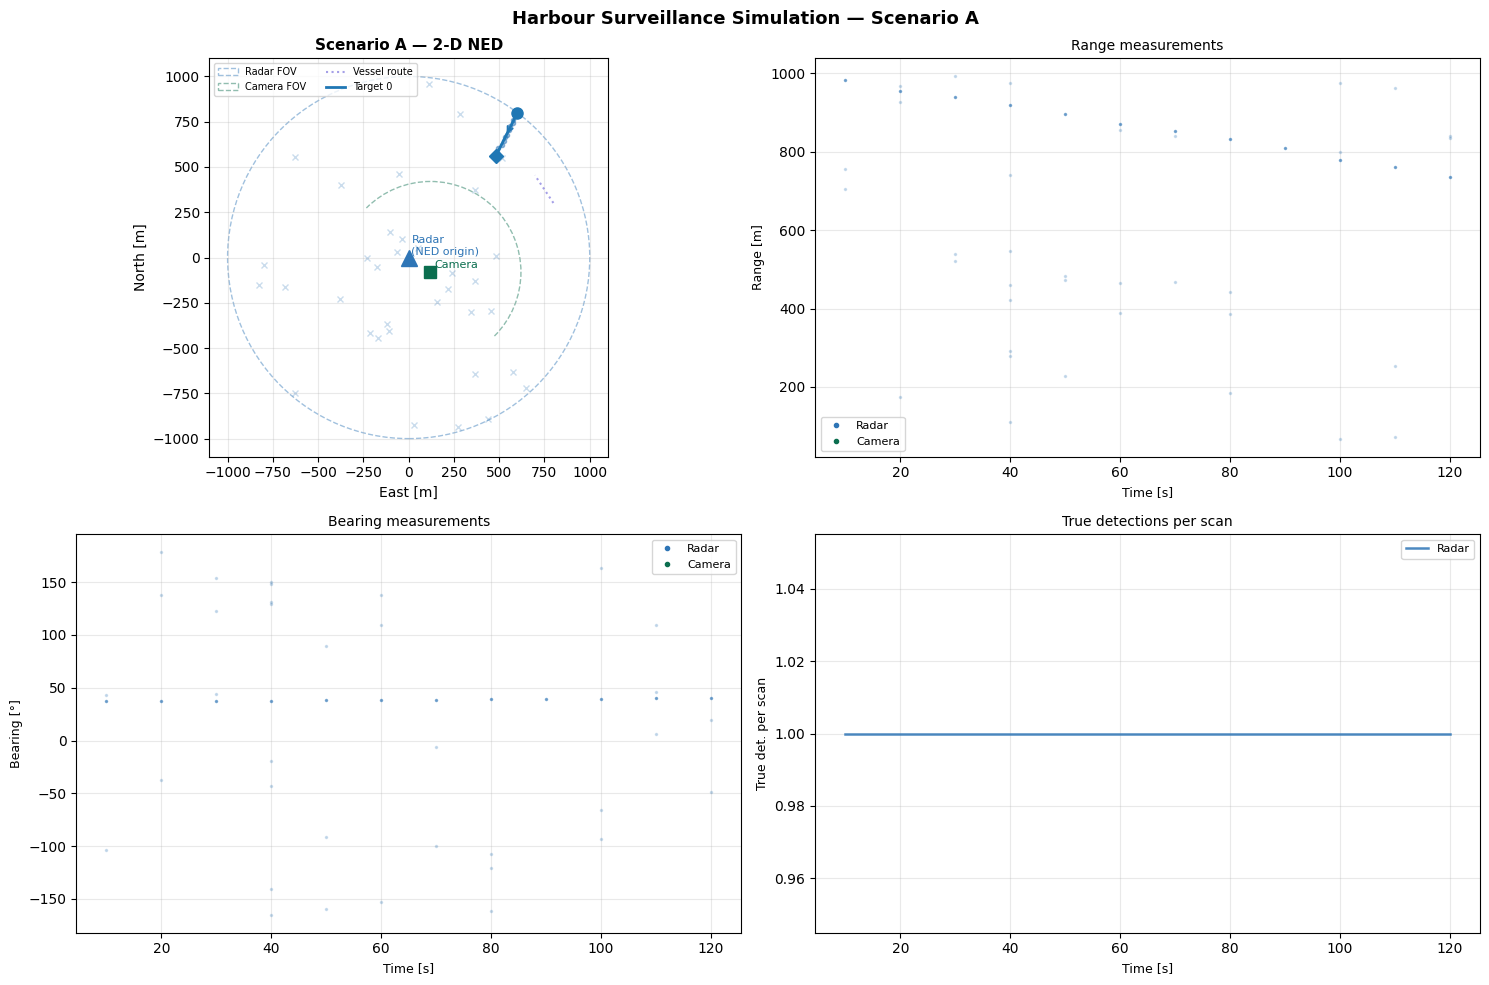

  Saved: harbour_sim_output/scenario_A.png
  Exported harbour_sim_output/scenario_A.json  (159.4 kB, 167 measurements)


'harbour_sim_output/scenario_A.json'

In [26]:
np.random.seed(42)
sim_A = make_sim()

targets_A = [
    TargetConfig(
        target_id=0,
        initial_north=800.0, initial_east=600.0,
        velocity_north=-2.0, velocity_east=-1.0,
        has_ais=False,
    )
]

output_A = sim_A.run(
    targets        = targets_A,
    t_end          = 120.0,
    scenario_name  = "A",
    active_sensors = ["radar", "gnss"],
)

print_summary(output_A)
plot_scenario(output_A)
export_json(output_A)


---
## Scenario B — Single target, radar + stereo camera

**Purpose**: validate multi-sensor EKF fusion and quantify the bearing-accuracy
benefit of adding the stereo camera.  The target crosses the camera's 180° FOV
between approximately t = 20 s and t = 80 s.

**Success criteria**:
- Quantitative RMSE improvement (camera fusion vs radar-only).
- NIS consistent for both sequential and centralised update architectures.



══════════════════════════════════════════════════════════
  Scenario B     |  duration: 120.0 s  |  targets: 1
──────────────────────────────────────────────────────────
  Sensor       Total  True det.  False alarms
──────────────────────────────────────────────────────────
  radar           41         12            29
  camera         174         56           118
  ais              0          0             0
  gnss           120        120             0
══════════════════════════════════════════════════════════



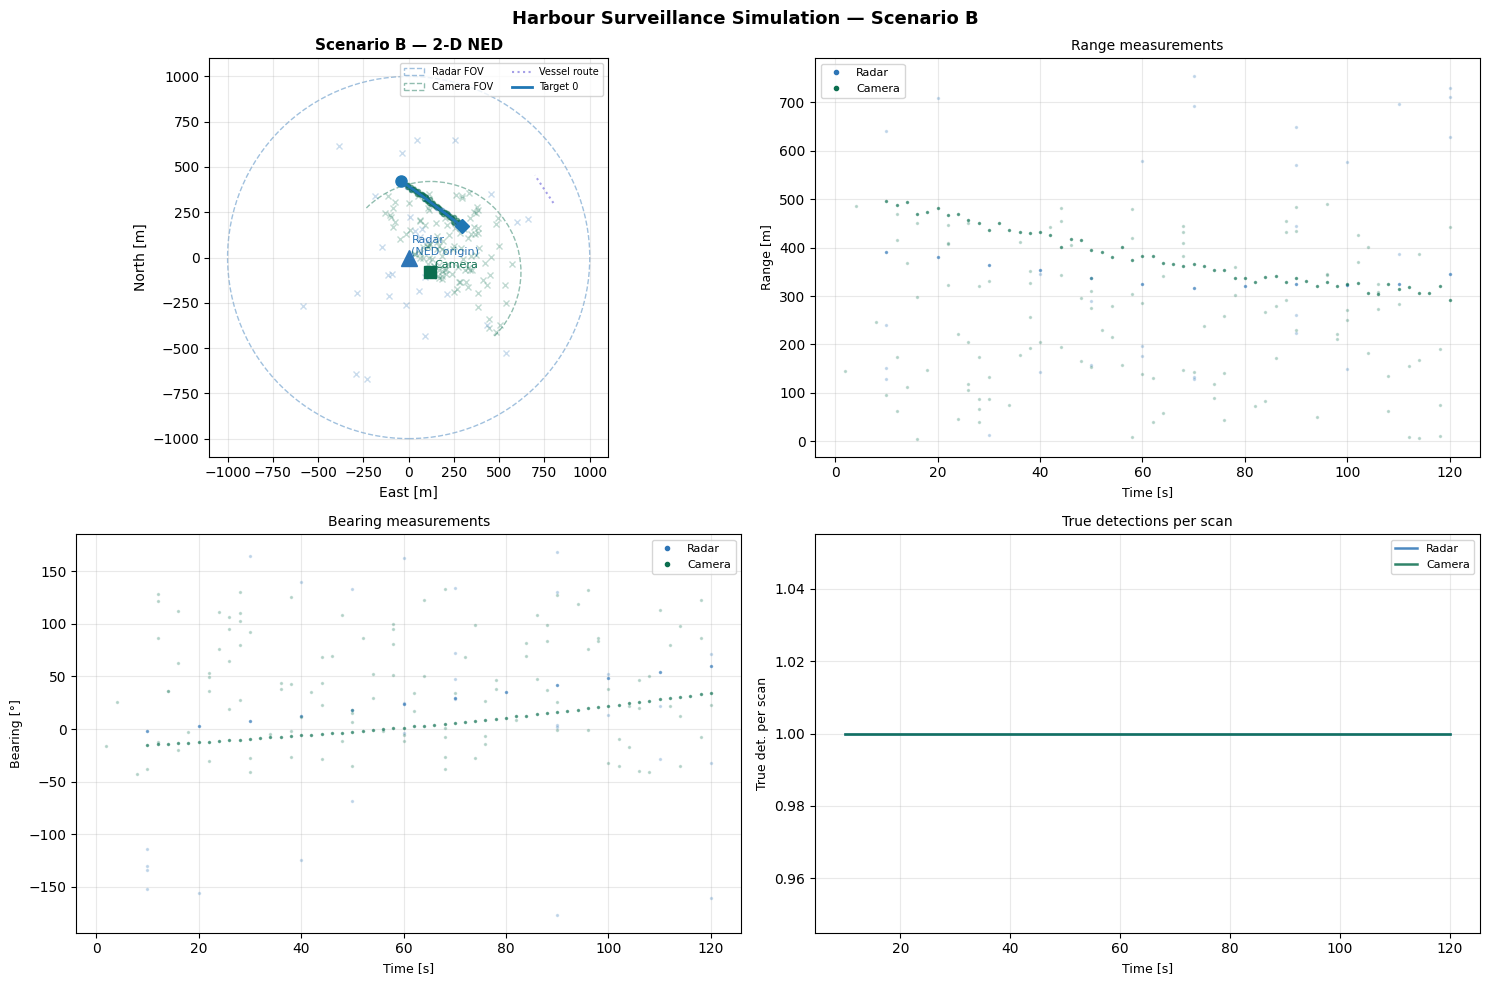

  Saved: harbour_sim_output/scenario_B.png
  Exported harbour_sim_output/scenario_B.json  (193.5 kB, 335 measurements)


'harbour_sim_output/scenario_B.json'

In [28]:
np.random.seed(42)
sim_B = make_sim()

targets_B = [
    TargetConfig(
        target_id=0,
        initial_north=420.0, initial_east=-40.0,
        velocity_north=-2.0, velocity_east=3.0,
        has_ais=False,
    )
]

output_B = sim_B.run(
    targets        = targets_B,
    t_end          = 120.0,
    scenario_name  = "B",
    active_sensors = ["radar", "camera", "gnss"],
)

print_summary(output_B)
plot_scenario(output_B)
export_json(output_B)

---
## Scenario C — AIS-equipped target with sensor dropout

**Purpose**: validate asynchronous AIS fusion and demonstrate coasting
through a 30-second AIS blackout.  All sensors are active.
The AIS transponder is switched off between t = 60 s and t = 90 s.

**Success criteria**:
- Both tracks survive the AIS dropout (coasting on radar + camera).
- RMSE lower with AIS than without during the AIS-available windows.
- Track re-acquires AIS smoothly after t = 90 s.



══════════════════════════════════════════════════════════
  Scenario C     |  duration: 150.0 s  |  targets: 1
──────────────────────────────────────────────────────────
  Sensor       Total  True det.  False alarms
──────────────────────────────────────────────────────────
  radar           53         15            38
  camera         158         18           140
  ais             41         38             3
  gnss           150        150             0
══════════════════════════════════════════════════════════



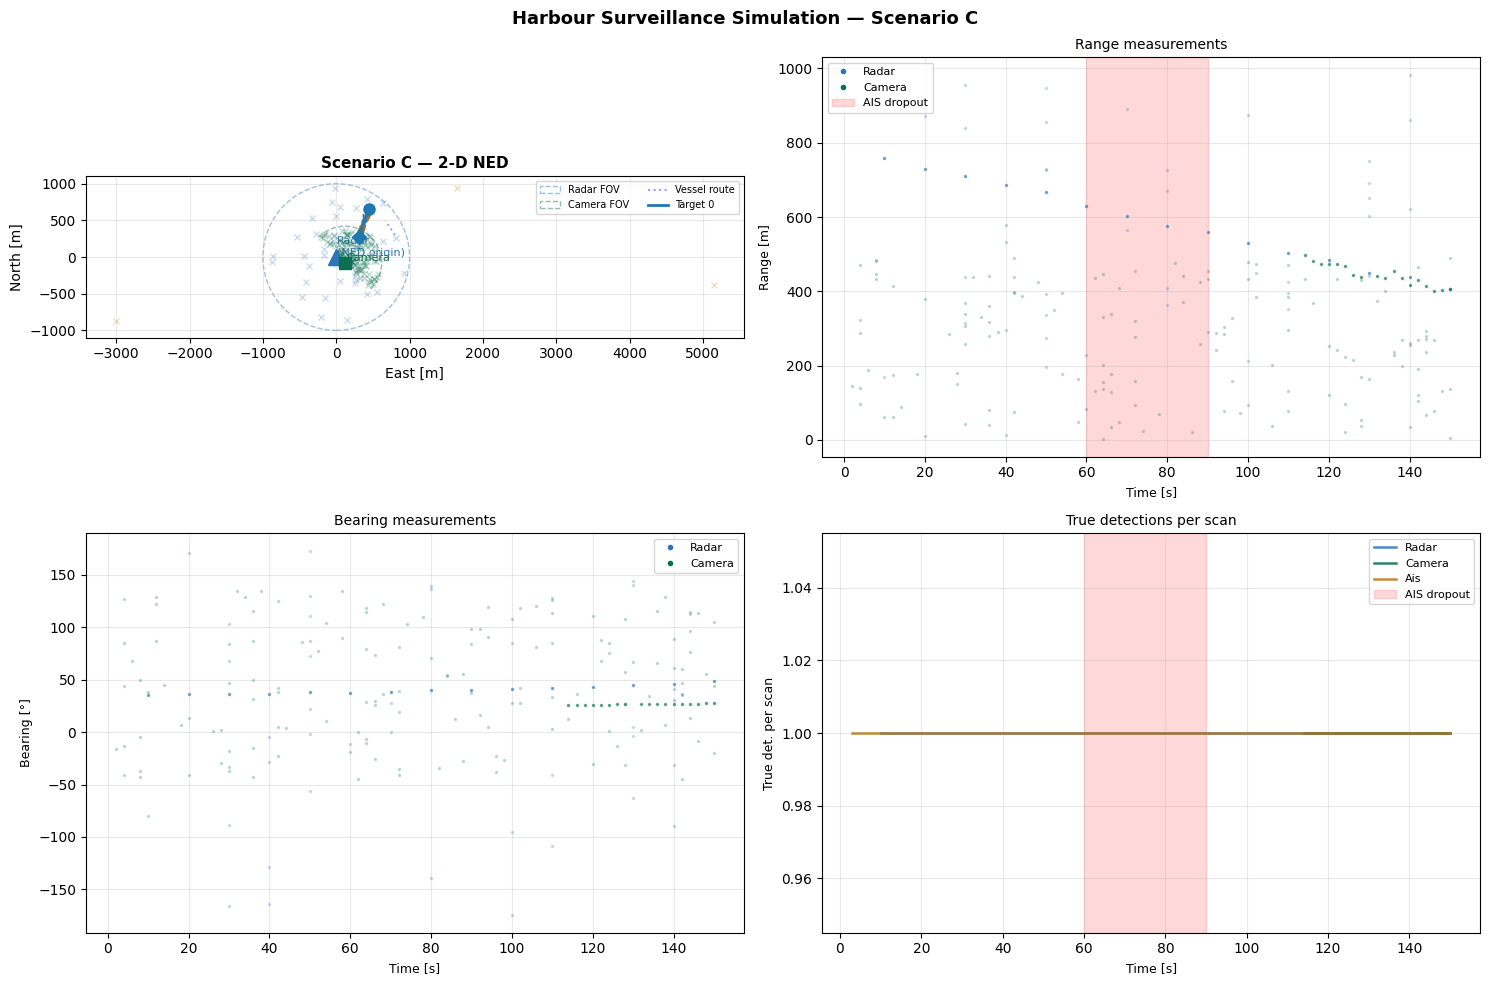

  Saved: harbour_sim_output/scenario_C.png
  Exported harbour_sim_output/scenario_C.json  (240.3 kB, 402 measurements)


'harbour_sim_output/scenario_C.json'

In [13]:
np.random.seed(42)
AIS_DROPOUT_C = (60.0, 90.0)
sim_C = make_sim()

targets_C = [
    TargetConfig(
        target_id=0,
        initial_north=650.0, initial_east=450.0,
        velocity_north=-2.5, velocity_east=-1.0,
        has_ais=True,
    )
]

output_C = sim_C.run(
    targets        = targets_C,
    t_end          = 150.0,
    scenario_name  = "C",
    active_sensors = ["radar", "camera", "ais", "gnss"],
    ais_dropout    = AIS_DROPOUT_C,
)

print_summary(output_C)
plot_scenario(output_C, ais_dropout=AIS_DROPOUT_C)
export_json(output_C)


---
## Scenario D — Multiple targets, crossing trajectories

**Purpose**: validate Mahalanobis gating, GNN association under gate conflicts,
and track identity preservation through a crossing event.

Four targets are placed on converging headings that bring them within
≈ 30 m of each other near NED position (430, 310) between t ≈ 48 s and t ≈ 72 s.

**Success criteria**:
- All 4 tracks confirmed and maintained throughout.
- No identity swap at the crossing.
- OSPA < 40 m during and after the crossing.



══════════════════════════════════════════════════════════
  Scenario D     |  duration: 120.0 s  |  targets: 4
──────────────────────────────────────────────────────────
  Sensor       Total  True det.  False alarms
──────────────────────────────────────────────────────────
  radar           98         44            54
  camera         231         43           188
  ais              0          0             0
  gnss           120        120             0
══════════════════════════════════════════════════════════



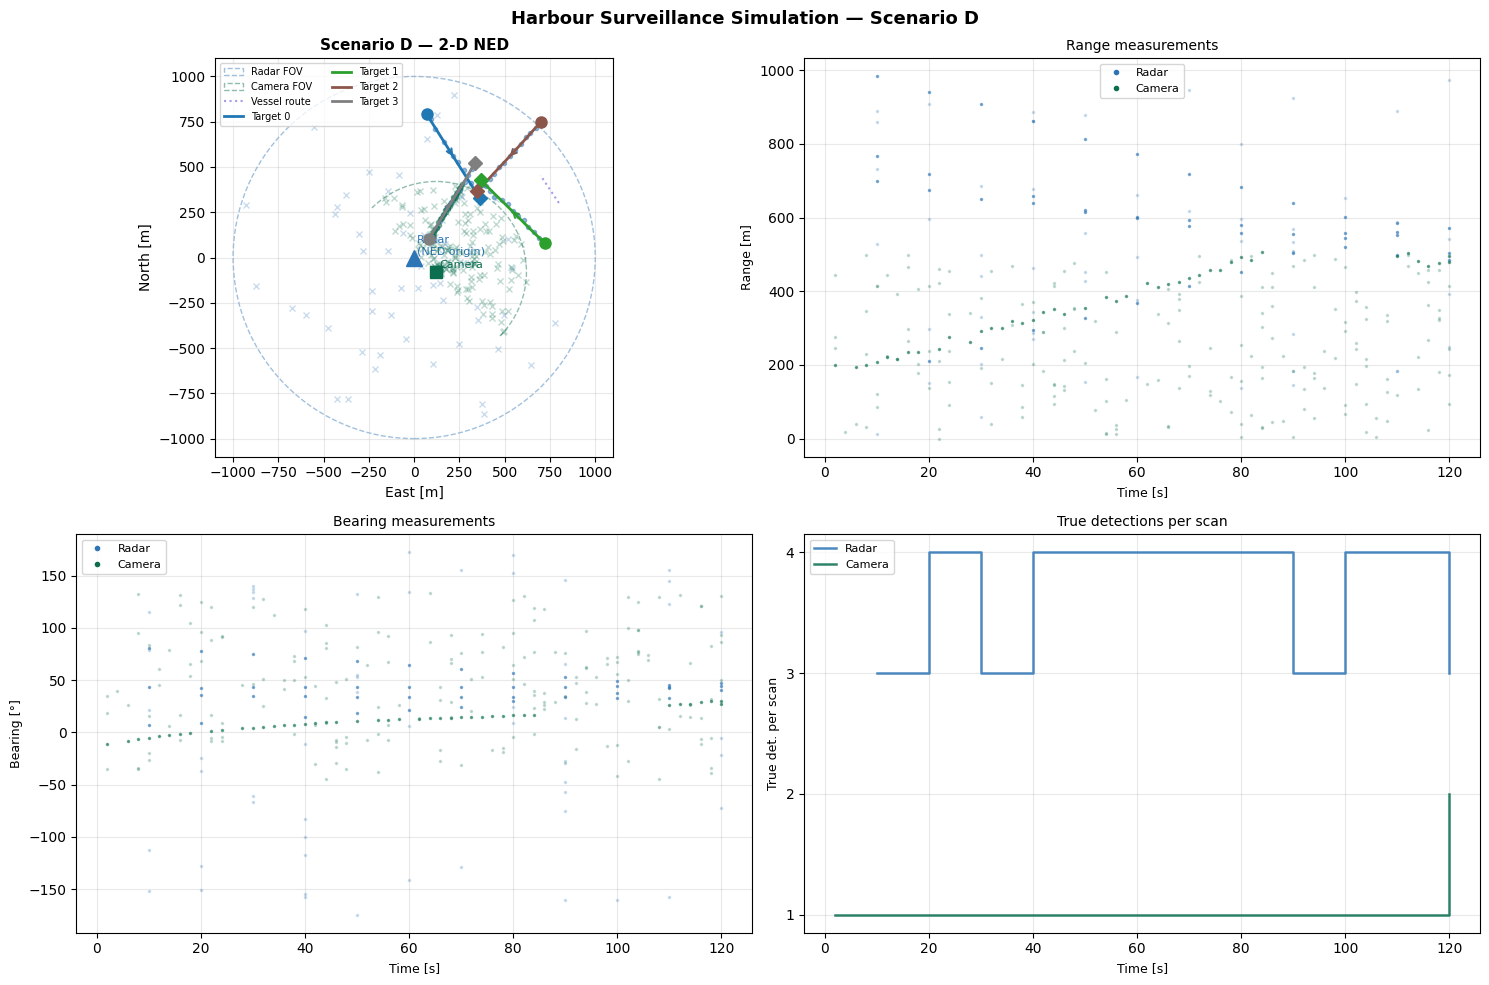

  Saved: harbour_sim_output/scenario_D.png
  Exported harbour_sim_output/scenario_D.json  (564.8 kB, 449 measurements)


'harbour_sim_output/scenario_D.json'

In [14]:
np.random.seed(42)
r_D, c_D, a_D, g_D = make_sensors(radar_pd=0.88, radar_lfa=5.0,
                                    camera_pd=0.88, camera_lfa=3.0)
v_D  = VesselTrajectory(DEFAULT_PATROL, speed_knots=3.0)
sim_D = HarbourSimulation(r_D, c_D, a_D, g_D, v_D)

# Targets designed to cross near (430, 310) at t ≈ 60 s
targets_D = [
    TargetConfig(target_id=0,
                 initial_north=790.0, initial_east=70.0,
                 velocity_north=-3.8, velocity_east=2.4),
    TargetConfig(target_id=1,
                 initial_north=80.0,  initial_east=720.0,
                 velocity_north=3.0,  velocity_east=-3.1),
    TargetConfig(target_id=2,
                 initial_north=750.0, initial_east=700.0,
                 velocity_north=-3.2, velocity_east=-2.8),
    TargetConfig(target_id=3,
                 initial_north=100.0, initial_east=80.0,
                 velocity_north=3.4,  velocity_east=2.1),
]

output_D = sim_D.run(
    targets        = targets_D,
    t_end          = 120.0,
    scenario_name  = "D",
    active_sensors = ["radar", "camera", "gnss"],
)

print_summary(output_D)
plot_scenario(output_D)
export_json(output_D)


---
## Scenario E — Mixed AIS / non-AIS harbour traffic

**Purpose**: validate the complete multi-target pipeline with realistic
harbour traffic: AIS-equipped commercial vessels and small craft without AIS,
targets entering and leaving the scene during the simulation.

**Configuration**:
- 3 AIS-equipped vessels (commercial traffic).
- 3 non-AIS small craft (invisible to AIS, radar + camera only).
- One AIS vessel enters at t = 30 s; one non-AIS vessel leaves at t = 100 s;
  one non-AIS vessel enters at t = 50 s.

**Success criteria**:
- All 6 targets tracked.
- Correct cardinality (track count) throughout.
- OSPA < 50 m throughout.



══════════════════════════════════════════════════════════
  Scenario E     |  duration: 180.0 s  |  targets: 6
──────────────────────────────────────────────────────────
  Sensor       Total  True det.  False alarms
──────────────────────────────────────────────────────────
  radar          181         85            96
  camera         422        164           258
  ais            180        164            16
  gnss           180        180             0
══════════════════════════════════════════════════════════



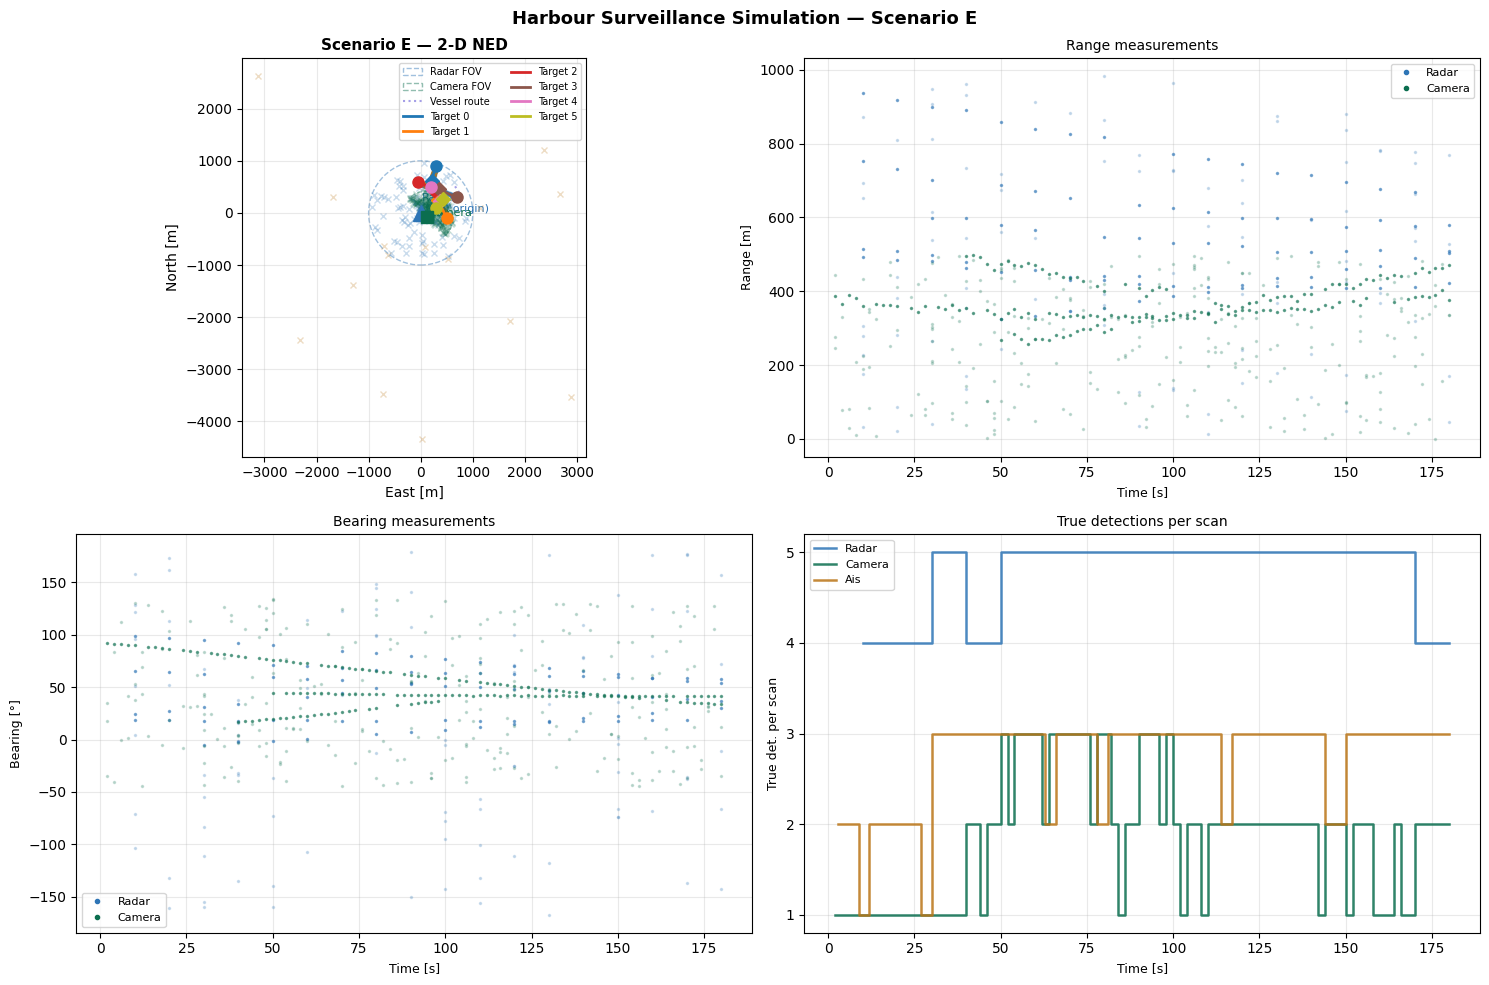

  Saved: harbour_sim_output/scenario_E.png
  Exported harbour_sim_output/scenario_E.json  (1102.9 kB, 963 measurements)


'harbour_sim_output/scenario_E.json'

In [15]:
np.random.seed(42)
r_E, c_E, a_E, g_E = make_sensors(radar_pd=0.90, radar_lfa=6.0,
                                    camera_pd=0.85, camera_lfa=3.0,
                                    ais_pd=0.98,    ais_lfa=0.2)
v_E  = VesselTrajectory(DEFAULT_PATROL, speed_knots=3.0)
sim_E = HarbourSimulation(r_E, c_E, a_E, g_E, v_E)

targets_E = [
    # ── AIS-equipped commercial vessels ─────────────────────────────────────
    TargetConfig(target_id=0,
                 initial_north=900.0, initial_east=300.0,
                 velocity_north=-1.5, velocity_east=-0.5,
                 has_ais=True),
    TargetConfig(target_id=1,
                 initial_north=-100.0, initial_east=500.0,
                 velocity_north=2.0,   velocity_east=-1.0,
                 has_ais=True),
    TargetConfig(target_id=2,
                 initial_north=600.0, initial_east=-50.0,
                 velocity_north=-1.0, velocity_east=2.0,
                 has_ais=True, active_from=30.0),   # enters at t=30 s
    # ── Non-AIS small craft ──────────────────────────────────────────────────
    TargetConfig(target_id=3,
                 initial_north=300.0, initial_east=700.0,
                 velocity_north=0.8,  velocity_east=-2.2,
                 has_ais=False),
    TargetConfig(target_id=4,
                 initial_north=500.0, initial_east=200.0,
                 velocity_north=-2.4, velocity_east=1.6,
                 has_ais=False, active_until=100.0),  # leaves at t=100 s
    TargetConfig(target_id=5,
                 initial_north=100.0, initial_east=300.0,
                 velocity_north=1.4,  velocity_east=0.9,
                 has_ais=False, active_from=50.0),    # enters at t=50 s
]

output_E = sim_E.run(
    targets        = targets_E,
    t_end          = 180.0,
    scenario_name  = "E",
    active_sensors = ["radar", "camera", "ais", "gnss"],
)

print_summary(output_E)
plot_scenario(output_E)
export_json(output_E)


---
## Section 9 — Load and inspect a saved scenario

The cell below demonstrates loading a previously exported JSON file
and inspecting its contents — the same interface the EKF tracker will use.


In [16]:
data = load_json(str(OUT_DIR / "scenario_D.json"))

print(f"Scenario      : {data['scenario_name']}")
print(f"Duration      : {data['t_end']} s")
print(f"Targets       : {list(data['ground_truth'].keys())}")
print(f"Measurements  : {len(data['measurements'])}")

# Show first 5 radar measurements
radar_meas = [m for m in data["measurements"] if m["sensor_id"] == "radar"]
print(f"\nFirst 5 radar measurements:")
for m in radar_meas[:5]:
    fa = " [FA]" if m["is_false_alarm"] else f" [tgt {m['target_id']}]"
    print(f"  t={m['time']:6.2f} s   r={m['range_m']:7.2f} m  "
          f"φ={np.rad2deg(m['bearing_rad']):7.2f}°{fa}")

# Show sensor configuration summary
print(f"\nSensor configurations:")
for sid, cfg in data["sensor_configs"].items():
    print(f"  {sid}: {cfg}")

print(f"\nAll output files in {OUT_DIR}/:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name:40s}  {f.stat().st_size/1024:6.1f} kB")


  Loaded  harbour_sim_output/scenario_D.json  (449 measurements)
Scenario      : D
Duration      : 120.0 s
Targets       : ['0', '1', '2', '3']
Measurements  : 449

First 5 radar measurements:
  t= 10.00 s   r= 767.98 m  φ=   6.79° [tgt 0]
  t= 10.00 s   r= 698.74 m  φ=  80.97° [tgt 1]
  t= 10.00 s   r= 982.76 m  φ=  43.24° [tgt 2]
  t= 10.00 s   r=  12.61 m  φ=  21.51° [FA]
  t= 10.00 s   r= 527.40 m  φ=  78.97° [FA]

Sensor configurations:
  radar: {'pos_ned': [0.0, 0.0], 'range_m': 1000.0, 'fov_deg': 360, 'rate_hz': 0.3, 'sigma_r_m': 5.0, 'sigma_phi_deg': 0.3, 'pd': 0.88, 'lambda_fa': 5.0}
  camera: {'pos_ned': [-80.0, 120.0], 'boresight_deg': 45.0, 'range_m': 500.0, 'fov_deg': 180, 'rate_hz': 0.5, 'sigma_r_m': 8.0, 'sigma_phi_deg': 0.15, 'pd': 0.88, 'lambda_fa': 3.0}
  ais: {'range_m': 5000.0, 'interval_s': 3.0, 'sigma_pos_m': 4.0, 'pd': 0.98}
  gnss: {'sigma_pos_m': 2.0, 'rate_hz': 1.0}

All output files in harbour_sim_output/:
  scenario_A.json                            159.4 kB

---
## Section 10 — Customisation guide for students

The simulation environment is fully configurable. Common customisations:

### Change sensor noise
```python
radar = RadarSensor(sigma_r=10.0, sigma_phi=np.deg2rad(0.5), ...)
```

### Add a target manoeuvre (coordinated turn approximation)
```python
# Add a velocity kick at a specific time step inside the simulation loop
# (subclass HarbourSimulation and override the propagation step)
```

### Disable a sensor
```python
output = sim.run(..., active_sensors=["radar", "gnss"])  # camera + AIS off
```

### Adjust false alarm density
```python
radar = RadarSensor(lambda_fa=8.0)  # denser clutter
```

### Change vessel speed
```python
vessel = VesselTrajectory(DEFAULT_PATROL, speed_knots=5.0)
```

### Reproduce exactly (fix random seed)
```python
np.random.seed(123)
output = sim.run(...)
```

### Extend to a coordinated-turn target
Replace the CV propagation in `HarbourSimulation.run()` with:
```python
# CT update (linearised, for small dt)
psi = np.arctan2(states[tid][3], states[tid][2])  # current heading
omega = 3.0 * np.pi / 180   # 3°/s turn rate
v     = np.linalg.norm(states[tid][2:4])
states[tid][0] += v * np.cos(psi) * dt
states[tid][1] += v * np.sin(psi) * dt
states[tid][2]  = v * np.cos(psi + omega * dt)
states[tid][3]  = v * np.sin(psi + omega * dt)
```
